Create : Let’s create a dumpy random dataset billing_churn.csv

In [2]:
import pandas as pd, numpy as np 
 
np.random.seed(42) 
n = 250 
df = pd.DataFrame({ 
    "customer_id": range(1001, 1001+n), 
    "usage_gb": np.random.gamma(5, 2, n).round(2),          # positively skewed usage 
    "call_mins": np.random.normal(350, 120, n).clip(50,900).round(0), 
    "complaints": np.random.poisson(0.6, n), 
    "plan_type": np.random.choice(["Prepaid","Postpaid"], n, p=[0.6,0.4]), 
    "region": np.random.choice(["Delhi","Mumbai","Chennai","Kolkata"], n) 
}) 
# create a realistic bill tied to usage, calls, plan, plus noise 
base = 99 + 8*df["usage_gb"] + 0.2*df["call_mins"] + 30*df["complaints"] 
base += np.where(df["plan_type"]=="Postpaid", 120, 0) 
df["monthly_bill"] = (base + np.random.normal(0, 40, n)).round(2) 
# churn probability higher for high complaints & low usage value users 
logit = -2.2 + 0.35*df["complaints"] - 0.002*(df["monthly_bill"]-200)
0.15*(df["usage_gb"]<5) 
prob = 1/(1+np.exp(-logit)) 
df["churn"] = np.where(np.random.rand(n)<prob, "Yes", "No") 
 
df.to_csv("billing_churn.csv", index=False) 
print("Saved billing_churn.csv with shape:", df.shape) 
df.head()

Saved billing_churn.csv with shape: (250, 8)


,customer_id,usage_gb,call_mins,complaints,plan_type,region,monthly_bill,churn
0,1001,11.65,427.0,2,Prepaid,Chennai,337.36,No
1,1002,8.75,514.0,0,Prepaid,Kolkata,305.34,No
2,1003,8.36,234.0,1,Prepaid,Mumbai,245.95,No
3,1004,8.36,432.0,0,Prepaid,Chennai,248.32,No
4,1005,17.95,477.0,0,Prepaid,Delhi,374.76,No


In [3]:

 
import pandas as pd 
df = pd.read_csv("billing_churn.csv") 
print(df.shape); df.head()

(250, 8)


,customer_id,usage_gb,call_mins,complaints,plan_type,region,monthly_bill,churn
0,1001,11.65,427.0,2,Prepaid,Chennai,337.36,No
1,1002,8.75,514.0,0,Prepaid,Kolkata,305.34,No
2,1003,8.36,234.0,1,Prepaid,Mumbai,245.95,No
3,1004,8.36,432.0,0,Prepaid,Chennai,248.32,No
4,1005,17.95,477.0,0,Prepaid,Delhi,374.76,No


PreProcessing

4) Basic preprocessing  
• Select numeric features for a simple start. 
• Encode churn to 0/1 for classification. 

In [6]:
import numpy as np 
num_features = ["usage_gb","call_mins","complaints"] 
X_num = df[num_features].copy() 
# Targets 
y_reg = df["monthly_bill"]               
# regression target 
y_clf = (df["churn"]=="Yes").astype(int) # classification target: Yes->1, No->0 


# 5) Train/test split (same split for both tasks)

In [8]:
 
from sklearn.model_selection import train_test_split 
X_train, X_test, y_reg_train, y_reg_test = train_test_split( 
X_num, y_reg, test_size=0.3, random_state=42) 
# Use the same split indices for classification 
_, _, y_clf_train, y_clf_test = train_test_split( 
X_num, y_clf, test_size=0.3, random_state=42) 

6) Model A  Linear Regression (predict monthly_bill) 
Train -> Predict -> Evaluate with RMSE (lower is better). 

=== REGRESSION ===
Features: ['usage_gb', 'call_mins', 'complaints']
Coefficients: {'usage_gb': np.float64(6.805), 'call_mins': np.float64(0.226), 'complaints': np.float64(34.865)}
Intercept: 150.35
RMSE: 71.07


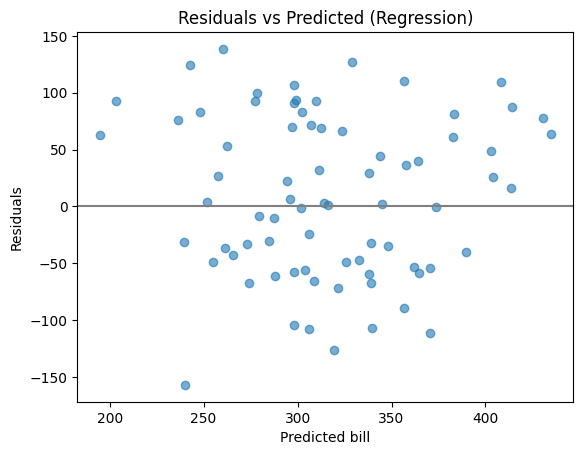


Saved new file with predictions → billing_churn_with_predictions.csv
Preview:
   customer_id  usage_gb  call_mins  complaints plan_type   region  \
0         1001     11.65      427.0           2   Prepaid  Chennai   
1         1002      8.75      514.0           0   Prepaid  Kolkata   
2         1003      8.36      234.0           1   Prepaid   Mumbai   
3         1004      8.36      432.0           0   Prepaid  Chennai   
4         1005     17.95      477.0           0   Prepaid    Delhi   

   monthly_bill churn  predicted_monthly_bill  
0        337.36    No                  396.07  
1        305.34    No                  326.31  
2        245.95    No                  295.10  
3        248.32    No                  305.08  
4        374.76    No                  380.54  


In [9]:

from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
reg = LinearRegression().fit(X_train, y_reg_train) 
y_reg_pred = reg.predict(X_test) 
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred)) 
print("=== REGRESSION ===") 
print("Features:", num_features) 
print("Coefficients:", dict(zip(num_features, reg.coef_.round(3)))) # how of each of the 
# parameter increase will impact the billing. 
print("Intercept:", round(reg.intercept_, 2)) 
print("RMSE:", round(rmse, 2)) 
import matplotlib.pyplot as plt 
resid = y_reg_test - y_reg_pred 
plt.scatter(y_reg_pred, resid, alpha=0.6) 
plt.axhline(0, color='gray') 
plt.xlabel("Predicted bill"); plt.ylabel("Residuals") 
plt.title("Residuals vs Predicted (Regression)") 
plt.show() 
df = pd.read_csv("billing_churn.csv") 
X_all = df[num_features] 
df["predicted_monthly_bill"] = reg.predict(X_all).round(2) 
output_path = "billing_churn_with_predictions.csv" 
df.to_csv(output_path, index=False) 
print(f"\nSaved new file with predictions → {output_path}") 
print("Preview:") 
print(df.head()) 